In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.datasets import make_blobs
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
%matplotlib inline

(250, 2) (250,)


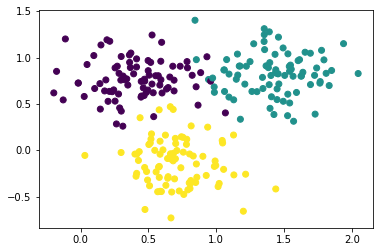

In [3]:
X, y = make_blobs(n_samples=250, centers=3, n_features=2, cluster_std=0.25, shuffle=True, center_box=(-2,2))
print(X.shape, y.shape)
plt.scatter(X[:,0], X[:,1], c=y)

In [4]:
y[:10]

array([2, 1, 0, 2, 0, 1, 0, 2, 2, 1])

In [11]:
y_vec = OneHotEncoder().fit_transform(y.reshape(-1, 1)).todense()
y_vec[:10]

matrix([[0., 0., 1.],
        [0., 1., 0.],
        [1., 0., 0.],
        [0., 0., 1.],
        [1., 0., 0.],
        [0., 1., 0.],
        [1., 0., 0.],
        [0., 0., 1.],
        [0., 0., 1.],
        [0., 1., 0.]])

In [17]:
x_train,x_test, y_train,y_test = train_test_split(X, y_vec, test_size=0.2)
print(x_train.shape,x_test.shape, y_train.shape,y_test.shape )

(200, 2) (50, 2) (200, 3) (50, 3)


In [31]:
class Model(torch.nn.Module):
    def __init__(self, input_size, hidden_size, op_size):
        super().__init__()
        self.input_size = input_size
        self.hidden_size  = hidden_size
        self.fc1 = nn.Linear(self.input_size, self.hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(self.hidden_size, op_size)
        self.softmax = nn.Softmax(dim=-1)
    def forward(self, x):
        hidden = self.fc1(x)
        relu = self.relu(hidden)
        output = self.fc2(relu)
        output = self.softmax(output)
        return output

In [55]:
model = Model(2, 10,3)
loss_function = torch.nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr = 0.25)

In [56]:
t = torch.tensor(x_test, dtype=torch.float32)
t.shape, t.dtype

(torch.Size([50, 2]), torch.float32)

In [57]:
model.eval()
y_pred = model(torch.tensor(x_test,dtype=torch.float32))
print(y_pred.shape)
loss_before_train = loss_function(y_pred.squeeze(), torch.tensor(y_test,dtype=torch.float32))
print('Test loss before training' , loss_before_train.item())

torch.Size([50, 3])
Test loss before training 0.6053571105003357


In [58]:
X_train=torch.tensor(x_train,dtype=torch.float32)
Y_train=torch.tensor(y_train,dtype=torch.float32)

model.train()
epoch = 100
for e in range(epoch):
    optimizer.zero_grad()
    # Forward pass
    y_pred = model(X_train)
    # Compute Loss
    _loss = loss_function(y_pred.squeeze(), Y_train)
   
    # print('Epoch {}: train loss: {}'.format(e, _loss.item()))
    # Backward pass
    _loss.backward()
    optimizer.step()

print('Epoch {}: train loss: {}'.format(epoch, _loss.item()))

Epoch 100: train loss: 0.16125604510307312


In [59]:
model.eval()
y_pred = model(torch.tensor(x_test,dtype=torch.float32))
print(y_pred.shape)
loss_after_train = loss_function(y_pred.squeeze(), torch.tensor(y_test,dtype=torch.float32))
print('Test loss After training' , loss_after_train.item())

torch.Size([50, 3])
Test loss After training 0.14102131128311157
